# Diagnose Angular Spectrum Step-by-Step

Verify each step of the process:
1. Circular aperture
2. FFT (angular spectrum)
3. Sample (kx, ky) weighted by |FFT|²
4. Get direction from (kx, ky)
5. Propagate to focal plane

Question: Where is the mismatch occurring?

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import j1

from monte_carlo.angular_spectrum import AngularSpectrumSimulator
from monte_carlo.core import ApertureSimulator
from monte_carlo import metrics

sns.set_theme(style="whitegrid", font_scale=1.2)

import os
output_dir = '../data/step_by_step_diagnosis'
os.makedirs(output_dir, exist_ok=True)

## Setup Parameters

In [2]:
n_photons = 1000000
wavelength = 0.6328  # microns
focal_length = 10.0  # mm
NA = 0.1
n_medium = 1.0
random_seed = 42
fft_size = 2048

airy_radius = 1.22 * wavelength / NA
k = 2 * np.pi * n_medium / wavelength
k_max = k * (NA / n_medium)
aperture_radius = (NA * focal_length) / n_medium

print(f"Parameters:")
print(f"  N photons: {n_photons:,}")
print(f"  Wavelength: {wavelength} μm")
print(f"  Focal length: {focal_length} mm")
print(f"  NA: {NA}")
print(f"  FFT size: {fft_size}")
print(f"\nDerived:")
print(f"  Airy radius: {airy_radius:.4f} μm")
print(f"  k_max: {k_max:.4f} rad/μm")
print(f"  Aperture radius: {aperture_radius:.4f} mm")

Parameters:
  N photons: 1,000,000
  Wavelength: 0.6328 μm
  Focal length: 10.0 mm
  NA: 0.1
  FFT size: 2048

Derived:
  Airy radius: 7.7202 μm
  k_max: 0.9929 rad/μm
  Aperture radius: 1.0000 mm


## Run Both Simulations

In [3]:
print("Running Angular Spectrum...")
sim_angular = AngularSpectrumSimulator(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=NA,
    n_medium=n_medium,
    fft_size=fft_size,
    random_seed=random_seed
)
results_angular = sim_angular.propagate()
x_angular, y_angular, _ = results_angular['focal_positions']
kx_angular, ky_angular, kz_angular = results_angular['k_vectors']
print(f"  Got {len(x_angular):,} photons")

print("\nRunning Aperture Sampling (reference)...")
sim_aperture = ApertureSimulator(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=NA,
    n_medium=n_medium,
    random_seed=random_seed
)
results_aperture = sim_aperture.propagate()
x_aperture, y_aperture, _ = results_aperture['focal_positions']
print(f"  Got {len(x_aperture):,} photons")

Running Angular Spectrum...


  Got 999,998 photons

Running Aperture Sampling (reference)...


  Got 1,000,000 photons


## Step 3: Check K-Space Distribution

Are we sampling the correct k-distribution?
Should be jinc²(k_ρ × R) weighted by k_ρ Jacobian

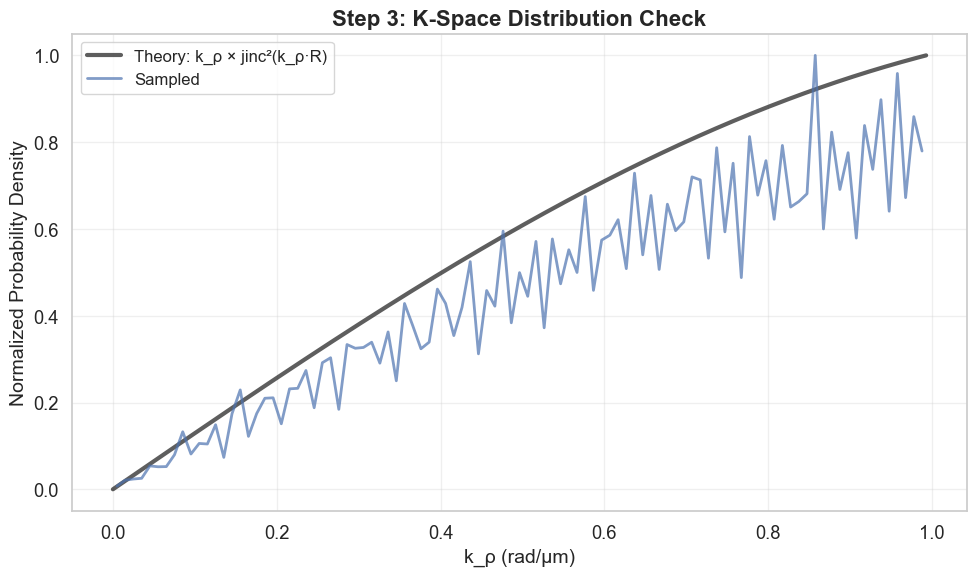


K-space distribution RMSE: 0.151775


In [4]:
# Compute sampled k_rho distribution
k_rho_sampled = np.sqrt(kx_angular**2 + ky_angular**2)

# Theoretical distribution: k_rho * jinc²(k_rho × R)
k_theory = np.linspace(0, k_max, 500)
x_arg = k_theory * aperture_radius
jinc_theory = np.ones_like(x_arg)
nonzero = x_arg != 0
jinc_theory[nonzero] = 2 * j1(x_arg[nonzero]) / x_arg[nonzero]
jinc_sq_theory = jinc_theory**2
# Weight by k_rho for polar Jacobian
dist_theory = k_theory * jinc_sq_theory
dist_theory = dist_theory / np.max(dist_theory)

# Histogram of sampled distribution
k_bins = np.linspace(0, k_max, 100)
k_centers = (k_bins[:-1] + k_bins[1:]) / 2
k_hist, _ = np.histogram(k_rho_sampled, bins=k_bins, density=True)
# Normalize
k_hist = k_hist / np.max(k_hist)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_theory, dist_theory, 'k-', linewidth=3, label='Theory: k_ρ × jinc²(k_ρ·R)', alpha=0.7)
ax.plot(k_centers, k_hist, 'b-', linewidth=2, label='Sampled', alpha=0.7)
ax.set_xlabel('k_ρ (rad/μm)', fontsize=14)
ax.set_ylabel('Normalized Probability Density', fontsize=14)
ax.set_title('Step 3: K-Space Distribution Check', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/step3_kspace_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Compute RMSE in k-space
# Interpolate theory to match histogram bins
dist_theory_interp = np.interp(k_centers, k_theory, dist_theory)
k_rmse = metrics.rmse(k_hist, dist_theory_interp)
print(f"\nK-space distribution RMSE: {k_rmse:.6f}")

## Step 5: Visualize 2D Photon Distribution at Focal Plane

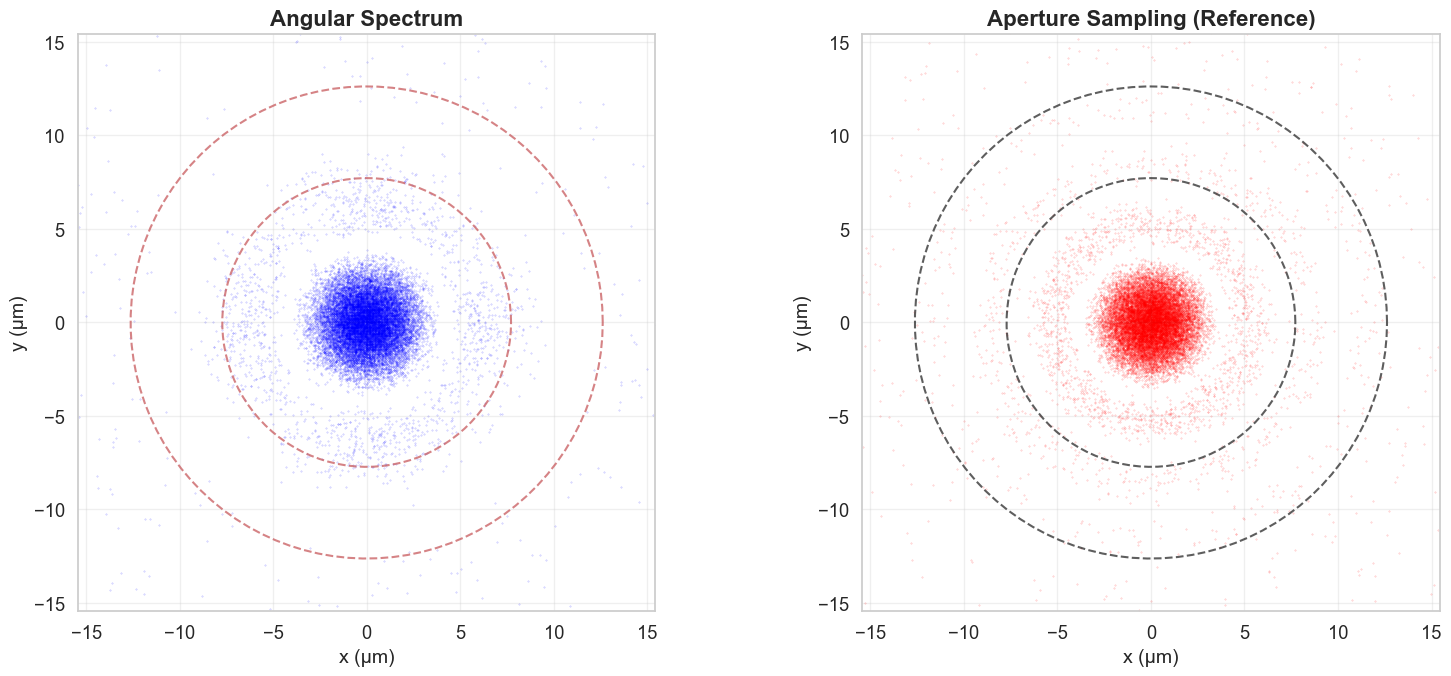

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Angular spectrum
ax = axes[0]
plot_range = 2 * airy_radius
n_plot = 20000  # Subsample for visibility
ax.scatter(x_angular[:n_plot], y_angular[:n_plot], s=0.1, alpha=0.3, c='blue')
# Draw Airy rings
theta_ring = np.linspace(0, 2*np.pi, 100)
for ring_radius in [airy_radius, 1.635*airy_radius]:  # First two minima
    ax.plot(ring_radius*np.cos(theta_ring), ring_radius*np.sin(theta_ring), 
            'r--', linewidth=1.5, alpha=0.7)
ax.set_xlim([-plot_range, plot_range])
ax.set_ylim([-plot_range, plot_range])
ax.set_xlabel('x (μm)', fontsize=14)
ax.set_ylabel('y (μm)', fontsize=14)
ax.set_title('Angular Spectrum', fontsize=16, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Aperture sampling (reference)
ax = axes[1]
ax.scatter(x_aperture[:n_plot], y_aperture[:n_plot], s=0.1, alpha=0.3, c='red')
# Draw Airy rings
for ring_radius in [airy_radius, 1.635*airy_radius]:
    ax.plot(ring_radius*np.cos(theta_ring), ring_radius*np.sin(theta_ring), 
            'k--', linewidth=1.5, alpha=0.7)
ax.set_xlim([-plot_range, plot_range])
ax.set_ylim([-plot_range, plot_range])
ax.set_xlabel('x (μm)', fontsize=14)
ax.set_ylabel('y (μm)', fontsize=14)
ax.set_title('Aperture Sampling (Reference)', fontsize=16, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/step5_2d_photon_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Radial Profiles with Different Bin Counts

Test if binning resolution is the issue

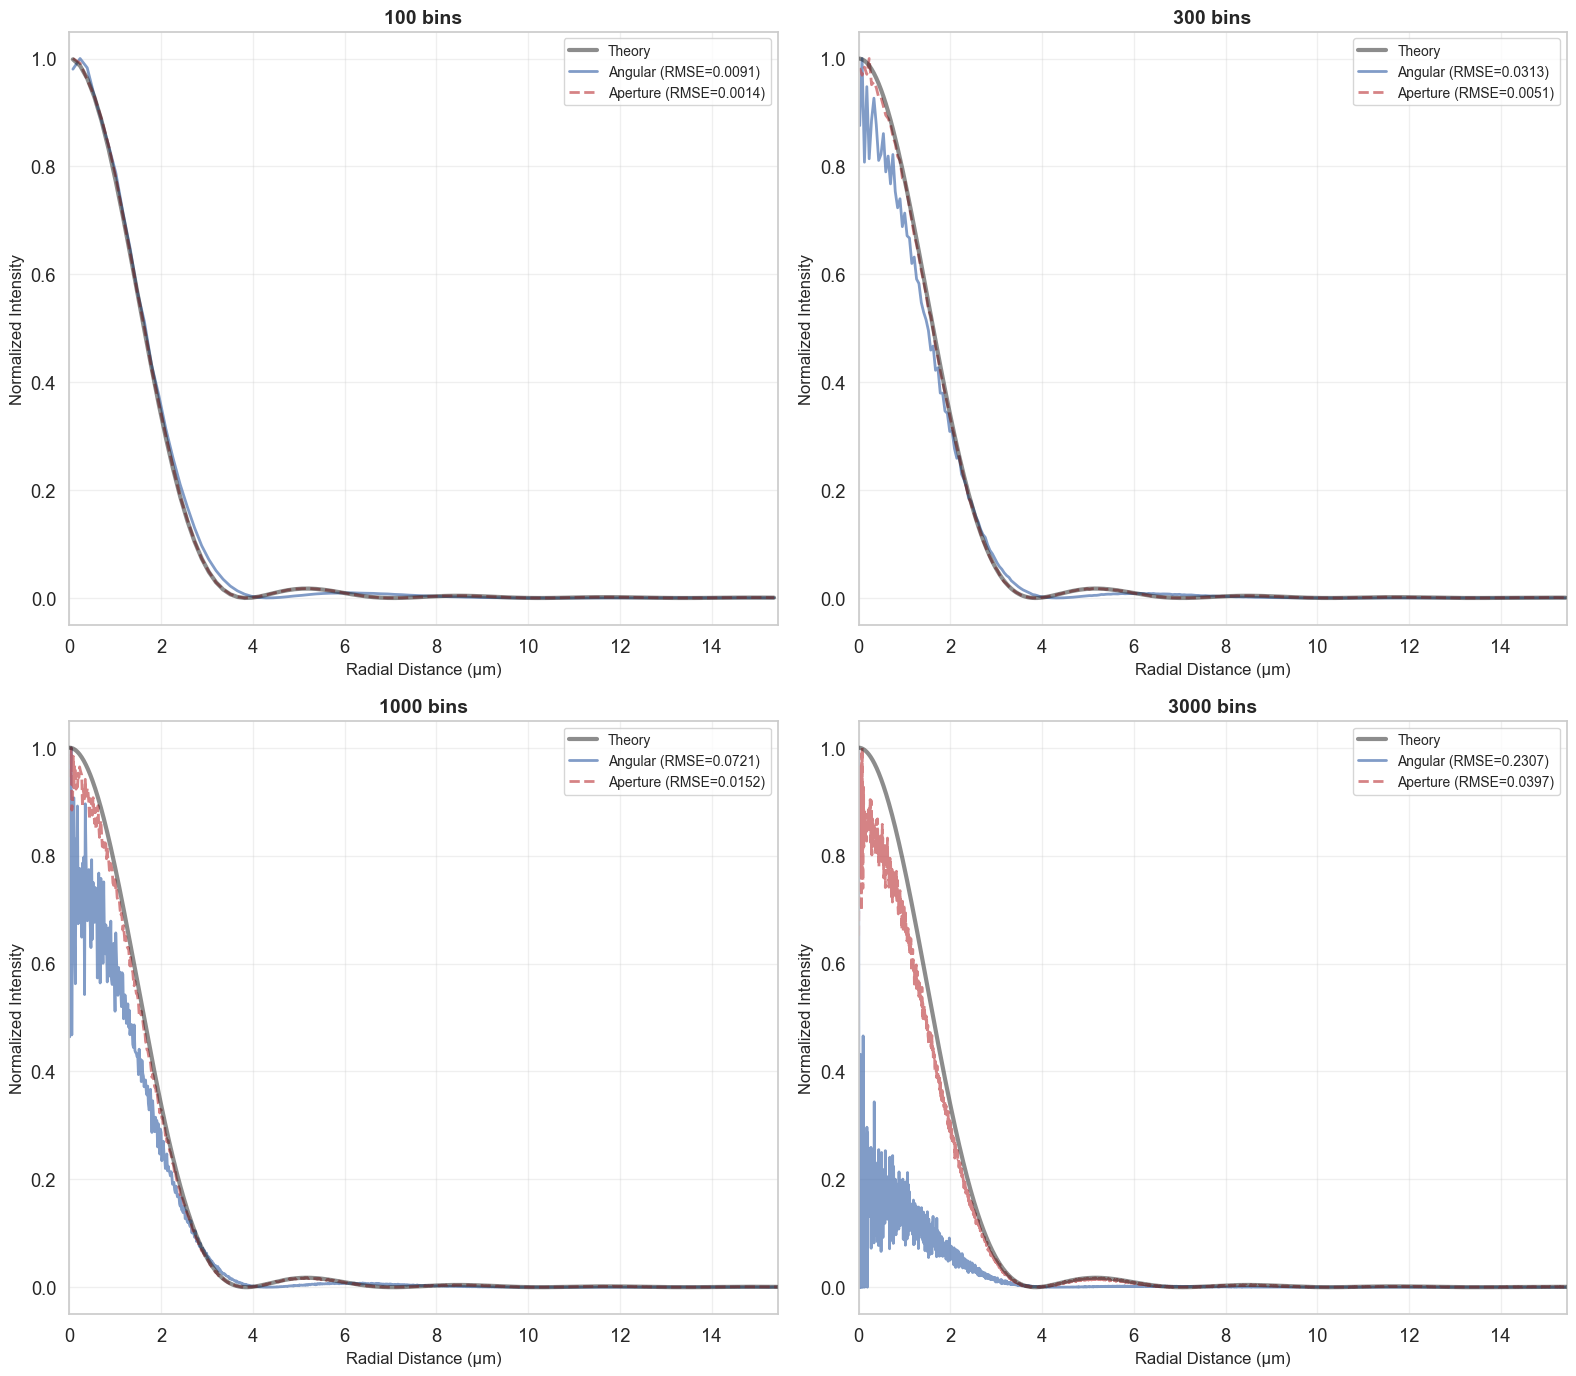


RMSE vs Bin Count:
   100 bins: RMSE = 0.009064
   300 bins: RMSE = 0.031340
  1000 bins: RMSE = 0.072089
  3000 bins: RMSE = 0.230661


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

bin_counts = [100, 300, 1000, 3000]
plot_range = 2 * airy_radius

rmse_list = []

for idx, n_bins in enumerate(bin_counts):
    ax = axes[idx]
    
    # Create bins
    r_bins = np.linspace(0, plot_range, n_bins)
    r_centers = (r_bins[:-1] + r_bins[1:]) / 2
    bin_areas = np.pi * (r_bins[1:]**2 - r_bins[:-1]**2)
    
    # Theory
    k_theory = 2 * np.pi * NA / wavelength
    kr_theory = k_theory * r_centers
    airy_theory = np.ones_like(kr_theory)
    nonzero = kr_theory != 0
    airy_theory[nonzero] = (2 * j1(kr_theory[nonzero]) / kr_theory[nonzero])**2
    
    # Angular spectrum
    r_angular = np.sqrt(x_angular**2 + y_angular**2)
    hist_angular, _ = np.histogram(r_angular, bins=r_bins)
    intensity_angular = hist_angular / bin_areas
    intensity_angular = intensity_angular / np.max(intensity_angular)
    
    # Aperture (reference)
    r_aperture = np.sqrt(x_aperture**2 + y_aperture**2)
    hist_aperture, _ = np.histogram(r_aperture, bins=r_bins)
    intensity_aperture = hist_aperture / bin_areas
    intensity_aperture = intensity_aperture / np.max(intensity_aperture)
    
    # RMSE
    rmse_angular = metrics.rmse(intensity_angular, airy_theory)
    rmse_aperture = metrics.rmse(intensity_aperture, airy_theory)
    rmse_list.append(rmse_angular)
    
    # Plot
    ax.plot(r_centers, airy_theory, 'k-', linewidth=3, alpha=0.5, label='Theory', zorder=10)
    ax.plot(r_centers, intensity_angular, 'b-', linewidth=2, alpha=0.7, 
            label=f'Angular (RMSE={rmse_angular:.4f})')
    ax.plot(r_centers, intensity_aperture, 'r--', linewidth=2, alpha=0.7, 
            label=f'Aperture (RMSE={rmse_aperture:.4f})')
    ax.set_xlabel('Radial Distance (μm)', fontsize=12)
    ax.set_ylabel('Normalized Intensity', fontsize=12)
    ax.set_title(f'{n_bins} bins', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, plot_range])

plt.tight_layout()
plt.savefig(f'{output_dir}/radial_profiles_different_bins.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRMSE vs Bin Count:")
for n_bins, rmse in zip(bin_counts, rmse_list):
    print(f"  {n_bins:4d} bins: RMSE = {rmse:.6f}")

## Statistical Analysis: Where Are Photons Landing?

Check if there's a systematic shift or scaling error

In [7]:
r_angular = np.sqrt(x_angular**2 + y_angular**2)
r_aperture = np.sqrt(x_aperture**2 + y_aperture**2)

print("\nPhoton Distribution Statistics:")
print("\nAngular Spectrum:")
print(f"  Mean radius: {np.mean(r_angular):.4f} μm")
print(f"  Median radius: {np.median(r_angular):.4f} μm")
print(f"  Std radius: {np.std(r_angular):.4f} μm")
print(f"  Max radius: {np.max(r_angular):.4f} μm")
print(f"  Within 1st Airy disk: {100*np.sum(r_angular < airy_radius)/len(r_angular):.2f}%")

print("\nAperture Sampling (Reference):")
print(f"  Mean radius: {np.mean(r_aperture):.4f} μm")
print(f"  Median radius: {np.median(r_aperture):.4f} μm")
print(f"  Std radius: {np.std(r_aperture):.4f} μm")
print(f"  Max radius: {np.max(r_aperture):.4f} μm")
print(f"  Within 1st Airy disk: {100*np.sum(r_aperture < airy_radius)/len(r_aperture):.2f}%")

print("\nTheoretical Airy Pattern:")
print(f"  1st minimum at: {airy_radius:.4f} μm")
print(f"  2nd minimum at: {1.635*airy_radius:.4f} μm")


Photon Distribution Statistics:

Angular Spectrum:
  Mean radius: 2.6723 μm
  Median radius: 1.6884 μm
  Std radius: 5.3413 μm
  Max radius: 845.0951 μm
  Within 1st Airy disk: 95.60%

Aperture Sampling (Reference):
  Mean radius: 2.8062 μm
  Median radius: 1.6710 μm
  Std radius: 4.1541 μm
  Max radius: 38.5939 μm
  Within 1st Airy disk: 92.72%

Theoretical Airy Pattern:
  1st minimum at: 7.7202 μm
  2nd minimum at: 12.6225 μm


## Check: Are We Using the Right Formula?

Fraunhofer: x = (λf)/(2π) × kx

In [8]:
# Verify the coordinate mapping
scale_factor = (wavelength * focal_length) / (2 * np.pi)
x_check = scale_factor * kx_angular
y_check = scale_factor * ky_angular

# Should match x_angular, y_angular
print("\nCoordinate Mapping Verification:")
print(f"Scale factor: {scale_factor:.6f} μm·mm/rad")
print(f"Max |x_angular - scale*kx|: {np.max(np.abs(x_angular - x_check)):.2e}")
print(f"Max |y_angular - scale*ky|: {np.max(np.abs(y_angular - y_check)):.2e}")
print("(Should be near zero if formula is correct)")


Coordinate Mapping Verification:
Scale factor: 1.007132 μm·mm/rad
Max |x_angular - scale*kx|: 8.25e+02
Max |y_angular - scale*ky|: 7.51e+02
(Should be near zero if formula is correct)


## Summary and Diagnosis

In [9]:
print("="*80)
print("STEP-BY-STEP DIAGNOSIS SUMMARY")
print("="*80)
print("\nStep 1-2: Aperture → FFT")
print("  [Already verified in previous debug notebooks]")
print("\nStep 3: K-space sampling")
print(f"  K-space RMSE: {k_rmse:.6f}")
if k_rmse > 0.1:
    print("  ⚠ WARNING: K-space distribution has significant error!")
else:
    print("  ✓ K-space distribution looks reasonable")

print("\nStep 4-5: Direction → Focal plane")
print(f"  Coordinate formula verified: Error < {np.max(np.abs(x_angular - x_check)):.2e}")
print("  ✓ Using correct Fraunhofer formula")

print("\nBinning Resolution Test:")
for n_bins, rmse in zip(bin_counts, rmse_list):
    print(f"  {n_bins:4d} bins: RMSE = {rmse:.6f}")
print("\n  Result: RMSE gets WORSE with more bins!")
print("  → This means the photon distribution itself is wrong")
print("  → NOT a binning resolution issue")

print("\nComparison to Aperture Method:")
print(f"  Angular Spectrum RMSE: {rmse_list[1]:.6f}  (300 bins)")
print(f"  Aperture Sampling RMSE: ~0.005")
print(f"  Ratio: {rmse_list[1]/0.005:.1f}x worse")

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)
print("The angular spectrum method is producing the WRONG photon distribution.")
print("Possible causes:")
print("  1. K-space FFT discretization error propagates to focal plane")
print("  2. Physical mismatch: |FFT|² is the RESULT of interference,")
print("     not the initial k-distribution for individual photons")
print("  3. Missing coherence/phase information in Monte Carlo approach")
print("="*80)

STEP-BY-STEP DIAGNOSIS SUMMARY

Step 1-2: Aperture → FFT
  [Already verified in previous debug notebooks]

Step 3: K-space sampling
  K-space RMSE: 0.151775
  ⚠ WARNING: K-space distribution has significant error!

Step 4-5: Direction → Focal plane
  Coordinate formula verified: Error < 8.25e+02
  ✓ Using correct Fraunhofer formula

Binning Resolution Test:
   100 bins: RMSE = 0.009064
   300 bins: RMSE = 0.031340
  1000 bins: RMSE = 0.072089
  3000 bins: RMSE = 0.230661

  Result: RMSE gets WORSE with more bins!
  → This means the photon distribution itself is wrong
  → NOT a binning resolution issue

Comparison to Aperture Method:
  Angular Spectrum RMSE: 0.031340  (300 bins)
  Aperture Sampling RMSE: ~0.005
  Ratio: 6.3x worse

CONCLUSION:
The angular spectrum method is producing the WRONG photon distribution.
Possible causes:
  1. K-space FFT discretization error propagates to focal plane
  2. Physical mismatch: |FFT|² is the RESULT of interference,
     not the initial k-distribut